# 📊 Exploratory Data Analysis — 9study Career & University Recommendation System

**Objective**: Phân tích dữ liệu từ database 9study để hiểu rõ phân phối, chất lượng dữ liệu, và chuẩn bị cho việc xây dựng Recommendation System.

**Safety**: Tất cả queries đều READ-ONLY. Không có INSERT/UPDATE/DELETE/DROP.

---
## 1. Setup & Configuration

In [1]:
# Cell 1: Import Libraries & Load Environment
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from collections import Counter

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Load environment
load_dotenv(override=True)
print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [2]:
# Cell 2: Database Connection (Safe, READ-ONLY)
DATABASE_URL = os.getenv("DATABASE_URL")
assert DATABASE_URL, "❌ DATABASE_URL not found in .env"

engine = create_engine(DATABASE_URL, echo=False)

# Verify connection
with engine.connect() as conn:
    result = conn.execute(text("SELECT version()"))
    pg_version = result.scalar()
    print(f"✅ Connected to PostgreSQL")
    print(f"   Version: {pg_version[:60]}...")
    
    # Count tables
    result = conn.execute(text(
        "SELECT COUNT(*) FROM information_schema.tables WHERE table_schema = 'public'"
    ))
    n_tables = result.scalar()
    print(f"   Tables in 'public' schema: {n_tables}")

✅ Connected to PostgreSQL
   Version: PostgreSQL 18.4 on x86_64-windows, compiled by msvc-19.44.35...
   Tables in 'public' schema: 47


---
## 2. Load Core Tables
Tải dữ liệu từ các bảng quan trọng nhất cho Recommendation System.

In [3]:
# Cell 3: Load Universities
df_universities = pd.read_sql(
    "SELECT * FROM universities WHERE deleted_at IS NULL",
    engine
)
print(f"🏛️ Universities: {len(df_universities)} rows × {df_universities.shape[1]} cols")
df_universities.head(3)

🏛️ Universities: 287 rows × 28 cols


,id,university_code,name,short_name,province,type,website,logo_url,credits_per_year,campus_count,featured_major,dean_year,de_an_year,de_an_source_url,de_an_official_pdf,de_an_source_type,de_an_audit_level,de_an_updated_at,overview_text,campus_text,student_note_heading,student_note_text,facts,tuition_status,created_at,updated_at,deleted_at,tuition_text
0,5a0b3998-6029-417a-8f53-7ded8033e85e,BVS,Học Viện Công Nghệ Bưu Chính Viễn Thông (Cơ sở TP.HCM),PTITHCM,TP.HCM,cong_lap,https://ptithcm.edu.vn,https://9study-media-storage.s3.ap-southeast-1.amazonaws.com/university-logo...,33.00,1.00,CNTT,2026.00,2026.00,src/features/university/data/de-an-data/BVS.ts,NaN,html-only,verbatim_strict,2026-06-10 15:18:11.398000+00:00,## Tổng quan và Vị thế\n\nHọc viện Công nghệ Bưu chính Viễn thông Cơ sở TP.H...,PTITHCM hiện vận hành hai cơ sở đào tạo tại TP.HCM: Trụ sở chính tại Quận 1 ...,Lưu ý quan trọng cho thí sinh,- Quy định về chứng chỉ ngoại ngữ: Học viện không chấp nhận chứng chỉ TOEFL ...,"{'Số campus': '1', 'Loại trường': 'Công lập', 'Tên viết tắt': 'PTITHCM', 'Ng...",applied,2026-06-08 19:57:15.099490,2026-06-11 15:00:59.805352,None,Học phí dự kiến với sinh viên chính quy: - Học phí trình độ đại hệ chính quy...
1,c00b2bb1-e3b5-4327-8d6d-3fb83cd92cdd,BMU,Trường Đại học Y Dược Buôn Ma Thuột,NaN,Đắk Lắk,tu_thuc,https://bmtu.edu.vn/,https://9study-media-storage.s3.ap-southeast-1.amazonaws.com/university-logo...,33.00,NaN,NaN,2026.00,2026.00,https://diemthi.tuyensinh247.com/de-an-tuyen-sinh/dai-hoc-y-duoc-buon-ma-thu...,https://images.tuyensinh247.com/picture/2026/0414/thong-tin-tuyen-sinh-truon...,html+pdf,normalized,2026-06-10 15:40:35.507000+00:00,NaN,NaN,NaN,NaN,{},applied,2026-06-08 19:57:14.977209,2026-06-09 14:40:17.054384,None,NaN
2,f6c8f59e-7796-488c-a1cc-5acfeaf861a6,SP2,Trường Đại Học Sư Phạm Hà Nội 2,HPU2,Vĩnh Phúc,cong_lap,https://hpu2.edu.vn,https://9study-media-storage.s3.ap-southeast-1.amazonaws.com/university-logo...,33.00,1.00,Sư phạm,2026.00,2026.00,src/features/university/data/de-an-data/SP2.ts,https://images.tuyensinh247.com/picture/2026/0326/thong-tin-tuyen-sinh-truon...,html+pdf,normalized,2026-06-10 15:40:46.654000+00:00,Trường Đại học Sư phạm Hà Nội 2 là trường đại học công lập với bề dày hơn 50...,"Trụ sở chính của trường hiện đặt tại số 32 Nguyễn Văn Linh, Phường Xuân Hòa,...",Lưu ý gần đây cho thí sinh,- Đăng ký nguyện vọng: Dù trúng tuyển sớm bằng học bạ hay điểm thi đánh giá ...,"{'Số campus': '1', 'Loại trường': 'Công lập', 'Tên viết tắt': 'HPU2', 'Ngành...",pending,2026-06-08 20:08:15.044607,2026-06-09 14:40:23.613853,None,NaN


In [4]:
# Cell 4: Load Programs (Ngành đào tạo)
df_programs = pd.read_sql(
    "SELECT * FROM programs WHERE deleted_at IS NULL",
    engine
)
print(f"📚 Programs: {len(df_programs)} rows × {df_programs.shape[1]} cols")
df_programs.head(3)

📚 Programs: 6669 rows × 18 cols

,id,university_id,major_code,major_name,program_type,specialization,major_group_id,total_quota,tuition_min,tuition_max,is_featured,featured_reason,featured_confidence,featured_source,created_at,updated_at,deleted_at,official_link
0,4a58a07a-4342-4a5e-823e-af587427e940,e4359383-0735-43d5-b704-eafd55c7e35d,7480201,Ngành Công nghệ thông tin (Thí sinh Nam),chuan,None,MG11,0.00,0.00,0.00,False,NaN,low,NaN,2026-06-08 20:07:24.247694,2026-06-08 20:13:48.937175,None,https://hvannd.edu.vn/bv/ct/17303/cap-nhat-thong-tin-tuyen-sinh-tuyen-moi-da...
1,985feceb-abad-444c-97b8-366363679339,e4359383-0735-43d5-b704-eafd55c7e35d,7860100,"Ngành Nghiệp vụ an ninh (Thí sinh Nam, vùng 1)",chuan,None,MG10,0.00,0.00,0.00,True,Khớp nhóm nổi bật: Nghiệp vụ An ninh,low,dsdaihoc,2026-06-08 20:07:24.247694,2026-06-08 20:13:48.937175,None,https://hvannd.edu.vn/bv/ct/17303/cap-nhat-thong-tin-tuyen-sinh-tuyen-moi-da...
2,6cf27b76-49e9-44e3-a66c-e3a6f902341b,e4359383-0735-43d5-b704-eafd55c7e35d,7860100,"Ngành Nghiệp vụ an ninh (Thí sinh Nam, vùng 2)",chuan,None,MG10,0.00,0.00,0.00,True,Khớp nhóm nổi bật: Nghiệp vụ An ninh,low,dsdaihoc,2026-06-10 15:41:45.218035,2026-06-10 15:41:45.218035,None,https://hvannd.edu.vn/bv/ct/17303/cap-nhat-thong-tin-tuyen-sinh-tuyen-moi-da...


In [5]:
# Cell 5: Load Major Groups (Nhóm ngành)
df_major_groups = pd.read_sql(
    "SELECT * FROM major_groups",
    engine
)
print(f"🏷️ Major Groups: {len(df_major_groups)} rows")
df_major_groups

🏷️ Major Groups: 35 rows


,id,name,icon
0,MG01,Kế toán - Kiểm toán,None
1,MG02,Tài chính - Ngân hàng,None
2,MG03,Kinh tế - Quản trị kinh doanh,None
3,MG04,Khoa học máy tính - Kỹ thuật phần mềm,None
4,MG05,Kỹ thuật máy tính - Mạng & Vi mạch,None
5,MG06,Marketing - Quan hệ công chúng,None
6,MG07,Sư phạm,None
7,MG08,Y - Dược,None
8,MG09,Nông - Lâm - Thú y,None
9,MG10,Quân sự - Công an,None


In [6]:
# Cell 6: Load Admission Scores (Điểm chuẩn)
df_admission_scores = pd.read_sql('''
    SELECT 
        a_s.id, a_s.program_admission_id, a_s.year, a_s.score, a_s.note,
        pa.program_id, pa.method, pa.exam_blocks,
        p.university_id, p.major_code, p.major_name, p.major_group_id,
        p.program_type, p.specialization, p.total_quota,
        p.tuition_min, p.tuition_max,
        u.university_code, u.name as university_name, u.province, u.type as university_type
    FROM admission_scores a_s
    JOIN program_admissions pa ON a_s.program_admission_id = pa.id
    JOIN programs p ON pa.program_id = p.id
    JOIN universities u ON p.university_id = u.id
    WHERE a_s.deleted_at IS NULL 
      AND pa.deleted_at IS NULL
      AND p.deleted_at IS NULL
      AND u.deleted_at IS NULL
''', engine)
print(f"📊 Admission Scores (enriched): {len(df_admission_scores)} rows × {df_admission_scores.shape[1]} cols")
df_admission_scores.head(3)

📊 Admission Scores (enriched): 25015 rows × 21 cols


,id,program_admission_id,year,score,note,program_id,method,exam_blocks,university_id,major_code,major_name,major_group_id,program_type,specialization,total_quota,tuition_min,tuition_max,university_code,university_name,province,university_type
0,019ea8df-5fe5-768f-9d5e-778687cea02c,019ea8df-5fe3-70c3-9440-8616a5b2f241,2025,26.38,None,7af9d0a1-adc8-439d-b42e-977b88f8fb7a,diem_thi_thpt,[],c2777b2a-4798-4dec-8eeb-53ebdb6e2480,7220201,Ngôn ngữ Anh (Thí sinh Nam),MG13,chuan,None,0.00,NaN,NaN,NQH,Học Viện Khoa Học Quân Sự - Hệ Quân sự,Hà Nội,cong_lap
1,019ea8df-5fea-732e-8241-67f112567406,019ea8df-5fe8-727b-9b47-6bd36fedb61c,2025,117.00,None,7af9d0a1-adc8-439d-b42e-977b88f8fb7a,dgnl_hn,[],c2777b2a-4798-4dec-8eeb-53ebdb6e2480,7220201,Ngôn ngữ Anh (Thí sinh Nam),MG13,chuan,None,0.00,NaN,NaN,NQH,Học Viện Khoa Học Quân Sự - Hệ Quân sự,Hà Nội,cong_lap
2,019ea8df-5fee-763e-bc85-69c611d91a6e,019ea8df-5feb-741f-b41a-500edc76b53a,2025,1040.00,None,7af9d0a1-adc8-439d-b42e-977b88f8fb7a,dgnl_hcm,[],c2777b2a-4798-4dec-8eeb-53ebdb6e2480,7220201,Ngôn ngữ Anh (Thí sinh Nam),MG13,chuan,None,0.00,NaN,NaN,NQH,Học Viện Khoa Học Quân Sự - Hệ Quân sự,Hà Nội,cong_lap


In [7]:
# Cell 7: Load Users
df_users = pd.read_sql(
    "SELECT id, created_at, name, email, role, status FROM users WHERE deleted_at IS NULL",
    engine
)
print(f"👤 Users: {len(df_users)} rows")
df_users.head()

👤 Users: 27 rows


,id,created_at,name,email,role,status
0,40,2026-06-08 13:04:33.707394,Test,itest-1780923873@test.local,user,active
1,2,2026-06-03 13:23:32.386079,Student 2,student2@yopmail.com,user,active
2,9,2026-06-04 03:27:28.144380,student2@yopmail.com,student4@yopmail.com,admin,active
3,10,2026-06-04 03:29:36.011769,student2@yopmail.com,student5@yopmail.com,admin,active
4,1,2026-06-03 13:23:32.386079,Student 1,student1@yopmail.com,user,active


In [8]:
# Cell 8: Load Exam Attempts (Lịch sử thi thử)
df_exam_attempts = pd.read_sql('''
    SELECT ea.*, e.title as exam_title, e.subject_id, s.name as subject_name
    FROM exam_attempts ea
    JOIN exams e ON ea.exam_id = e.id
    LEFT JOIN subjects s ON e.subject_id = s.id
    WHERE ea.deleted_at IS NULL
''', engine)
print(f"📝 Exam Attempts: {len(df_exam_attempts)} rows")
df_exam_attempts.head()

📝 Exam Attempts: 12 rows


,id,user_id,exam_id,status,started_at,last_active_at,submitted_at,duration_seconds,score,correct_count,total_questions,metadata,deleted_at,created_at,updated_at,exam_title,subject_id,subject_name
0,019ea2f4-8876-70c2-a354-b9543983acf2,31,4051581b-4c16-40fa-bef7-ca43cccd1e7f,in_progress,2026-06-07 16:39:55.253000+00:00,2026-06-07 16:39:58.027000+00:00,NaT,5400,NaN,NaN,22,"{'answers': {'mc': {'f091461e-35db-4326-a9b3-da4764c6fc99': 'C'}, 'tf': {}, ...",None,2026-06-07 16:39:55.254016,2026-06-07 16:39:58.034441,Đề khảo sát chất lượng THPT môn Toán trường THPT Nguyễn Đăng Đạo Sở GD&ĐT Bắ...,b32ebb42-92bc-4dcd-b280-2dd5c81e4fd4,Toán
1,019ea1eb-1581-70ea-b385-27e438ea1bcf,31,b2fafe05-2d74-46c8-bf68-62639fd12e3e,in_progress,2026-06-07 11:49:58.779000+00:00,2026-06-08 17:24:12.136000+00:00,NaT,5400,NaN,NaN,22,"{'answers': {'mc': {'10cc14bc-7661-480a-965d-b6b54040ebaa': 'D', '14e7feb7-0...",None,2026-06-07 11:49:58.781636,2026-06-08 17:24:12.141579,Đề khảo sát chất lượng THPT môn Toán trường THPT Thuận Thành Số 1 Sở GD&ĐT B...,b32ebb42-92bc-4dcd-b280-2dd5c81e4fd4,Toán
2,019ea779-244c-74b5-bc87-2886e73dd086,31,3aa9f9a2-c6c2-42c9-89af-a8808f4f3a7d,in_progress,2026-06-08 13:43:14.764000+00:00,2026-06-08 17:24:12.357000+00:00,NaT,5400,NaN,NaN,22,"{'answers': {'mc': {}, 'tf': {}, 'short': {}}, 'currentIdx': 16}",None,2026-06-08 13:43:14.760472,2026-06-08 17:24:12.359132,Đề khảo sát chất lượng THPT môn Toán trường THPT Nguyễn Khuyến & Lê Thánh Tô...,b32ebb42-92bc-4dcd-b280-2dd5c81e4fd4,Toán
3,019ea2f4-886f-70dd-b497-84f082e995bf,31,4051581b-4c16-40fa-bef7-ca43cccd1e7f,in_progress,2026-06-07 16:39:55.241000+00:00,NaT,NaT,5400,NaN,NaN,22,"{'answers': {'mc': {}, 'tf': {}, 'short': {}}, 'currentIdx': 0}",None,2026-06-07 16:39:55.242344,2026-06-07 16:39:55.242344,Đề khảo sát chất lượng THPT môn Toán trường THPT Nguyễn Đăng Đạo Sở GD&ĐT Bắ...,b32ebb42-92bc-4dcd-b280-2dd5c81e4fd4,Toán
4,019ed267-8a22-76dd-b6a8-1acab3d2ab08,53,b2fafe05-2d74-46c8-bf68-62639fd12e3e,submitted,2026-06-16 21:47:41.474000+00:00,2026-06-16 21:51:15.495000+00:00,2026-06-16 21:51:15.766000+00:00,214,0.75,0.00,22,"{'result': {'total': 22, 'byType': {'SHORT_ANSWER': {'max': 3, 'total': 6, '...",None,2026-06-16 21:47:41.469047,2026-06-16 21:51:15.767498,Đề khảo sát chất lượng THPT môn Toán trường THPT Thuận Thành Số 1 Sở GD&ĐT B...,b32ebb42-92bc-4dcd-b280-2dd5c81e4fd4,Toán


In [9]:
# Cell 9: Load Subjects
df_subjects = pd.read_sql(
    "SELECT * FROM subjects WHERE deleted_at IS NULL ORDER BY sort_order",
    engine
)
print(f"📖 Subjects: {len(df_subjects)} rows")
df_subjects[['id', 'name', 'short_name', 'sort_order']]

📖 Subjects: 16 rows


,id,name,short_name,sort_order
0,a379cce7-3eae-4295-b1ae-d45df462fb10,Tư duy Toán học,Toán,1
1,82f39ae4-6dce-4a65-bd6e-b7ec2f6032ea,Toán & Xử lý số liệu,Toán,1
2,b32ebb42-92bc-4dcd-b280-2dd5c81e4fd4,Toán,Toán,1
3,8c983e1a-ddd8-4523-b267-80500748face,Ngữ văn,Văn,2
4,4198c43b-3d46-433d-80c4-f9da334ff81d,Ngôn ngữ,Văn,2
5,ae7c87f4-fb27-47e2-ae1c-f3d0d93ad6c3,Giải quyết vấn đề,GQVĐ,2
6,374f15d2-3dd6-4866-98c2-bd42fa6a4c04,Tư duy Khoa học,KHTN,3
7,10fd7474-dcb8-4618-a2f4-943b16814907,Tiếng Anh,Anh,3
8,064dfaa5-8e83-42ba-9126-bf7cb25f0812,Vật lý,Lý,4
9,63b84356-7654-4f76-98fa-ddcf05858bbe,Khoa học,KHTN,4


In [10]:
# Cell 10: Load Admission Methods
df_admission_methods = pd.read_sql('''
    SELECT am.*, u.name as university_name, u.university_code
    FROM admission_methods am
    JOIN universities u ON am.university_id = u.id
    WHERE am.deleted_at IS NULL AND u.deleted_at IS NULL
''', engine)
print(f"🔑 Admission Methods: {len(df_admission_methods)} rows")
df_admission_methods.head(3)

🔑 Admission Methods: 1201 rows


,id,university_id,number,title,subtitle,method_categories,markdown,slots,sort_order,created_at,updated_at,deleted_at,university_name,university_code
0,e4d5e132-9693-4a53-a59a-221d9b91cf3e,9450bcba-ad19-473f-8d2c-dd94261d201f,4,PT4: Xét kết quả đánh giá tư duy năm 2026 của Đại học Bách khoa Hà Nội,NaN,[dg_tu_duy],NaN,"[{'kind': 'evidence', 'label': 'Quy chế', 'evidence': {'text': 'Xét tuyển th...",3,2026-06-10 15:41:52.651070,2026-06-10 15:41:52.651070,None,Trường Đại Học Giao Thông Vận Tải,GHA
1,370bdcae-79d9-47d8-a0e8-89dff79c46d0,d80af3ff-a83d-4a53-92ca-a96f639d2afd,1,Điểm thi THPT,NaN,[diem_thi_thpt],#### Quy chế\n\n##### Điều kiện xét tuyển\n\n- Thí sinh đã tốt nghiệp THPT.\...,[],0,2026-06-10 15:41:47.071240,2026-06-10 15:41:47.071240,None,Trường Đại Học Bách Khoa Đà Nẵng,DDK
2,42e49cfc-179f-43c2-9280-c89bff69d675,a728ba88-2f86-48a8-b72d-0a283a8986cd,4,Điểm Đánh giá Tư duy,NaN,[],4.1 Đối tượng\n\nPhương thức xét tuyển dựa trên kết quả kỳ thi Đánh giá tư d...,[],3,2026-06-10 15:41:49.490232,2026-06-10 15:41:49.490232,None,Trường Đại Học Lao Động – Xã Hội (Cơ sở II),DLS


---
## 3. Data Quality Profiling
Kiểm tra missing values, data types, và tình trạng dữ liệu tổng thể.

In [11]:
# Cell 11: Missing Values Analysis — All Core Tables
def missing_report(df, name):
    """Generate a missing values report for a DataFrame."""
    total = len(df)
    missing = df.isnull().sum()
    missing_pct = (missing / total * 100).round(2)
    
    report = pd.DataFrame({
        'Column': missing.index,
        'Missing': missing.values,
        'Missing %': missing_pct.values,
        'Dtype': df.dtypes.values
    })
    report = report[report['Missing'] > 0].sort_values('Missing %', ascending=False)
    
    if len(report) == 0:
        print(f"  ✅ {name}: No missing values!")
    else:
        print(f"  ⚠️ {name}: {len(report)} columns with missing values")
        print(report.to_string(index=False))
    print()
    return report

print("=" * 70)
print("📋 MISSING VALUES REPORT")
print("=" * 70)

datasets = {
    'Universities': df_universities,
    'Programs': df_programs,
    'Major Groups': df_major_groups,
    'Admission Scores (enriched)': df_admission_scores,
    'Users': df_users,
    'Exam Attempts': df_exam_attempts,
    'Subjects': df_subjects,
}

missing_reports = {}
for name, df in datasets.items():
    missing_reports[name] = missing_report(df, name)

📋 MISSING VALUES REPORT
  ⚠️ Universities: 21 columns with missing values
              Column  Missing  Missing %               Dtype
          deleted_at      287     100.00              object
   student_note_text      177      61.67                 str
student_note_heading      177      61.67                 str
        tuition_text      177      61.67                 str
        campus_count      170      59.23             float64
         campus_text      170      59.23                 str
      featured_major      170      59.23                 str
          short_name      168      58.54                 str
       overview_text      152      52.96                 str
  de_an_official_pdf      127      44.25                 str
    credits_per_year       42      14.63             float64
            province       41      14.29                 str
                type       41      14.29                 str
             website       41      14.29                 str
           

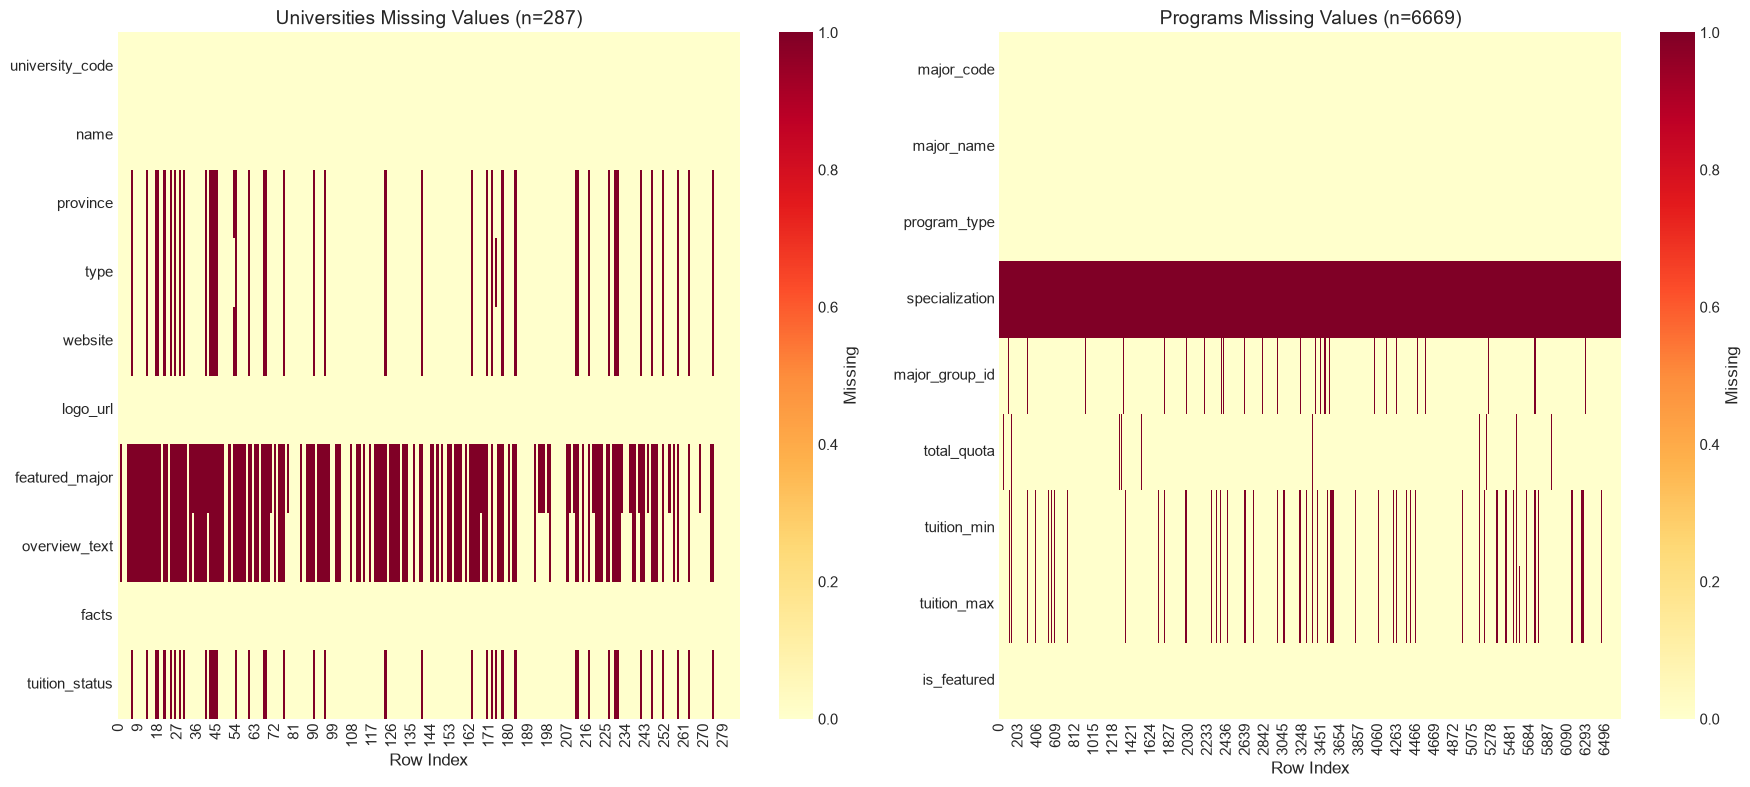

💾 Saved: plots/missing_values_heatmap.png


In [12]:
# Cell 12: Missing Values Heatmap — Universities & Programs
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Universities
uni_cols = ['university_code', 'name', 'province', 'type', 'website', 
            'logo_url', 'featured_major', 'overview_text', 'facts', 'tuition_status']
uni_missing = df_universities[uni_cols].isnull()
sns.heatmap(uni_missing.T, cbar=True, yticklabels=True, ax=axes[0],
            cmap='YlOrRd', cbar_kws={'label': 'Missing'})
axes[0].set_title(f'Universities Missing Values (n={len(df_universities)})')
axes[0].set_xlabel('Row Index')

# Programs
prog_cols = ['major_code', 'major_name', 'program_type', 'specialization',
             'major_group_id', 'total_quota', 'tuition_min', 'tuition_max', 'is_featured']
prog_missing = df_programs[prog_cols].isnull()
sns.heatmap(prog_missing.T, cbar=True, yticklabels=True, ax=axes[1],
            cmap='YlOrRd', cbar_kws={'label': 'Missing'})
axes[1].set_title(f'Programs Missing Values (n={len(df_programs)})')
axes[1].set_xlabel('Row Index')

plt.tight_layout()
plt.savefig('plots/missing_values_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: plots/missing_values_heatmap.png")

---
## 4. Data Distributions
Phân tích phân phối điểm chuẩn, ngành nghề, trường học.

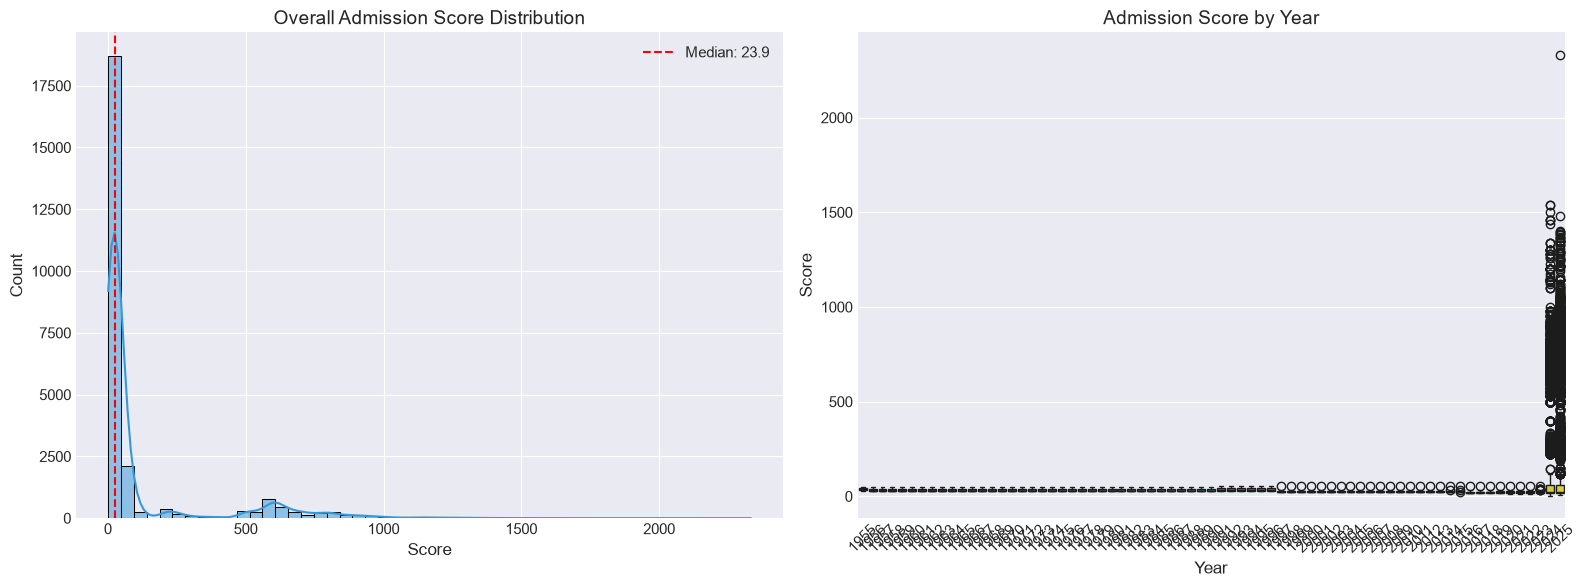

📊 Score Statistics:
        count   mean    std   min   25%   50%   75%     max
year                                                       
1955     2.00  39.42  13.89 29.60 34.51 39.42 44.33   49.24
1956     3.00  35.18  12.26 26.70 28.15 29.60 39.42   49.24
1957     3.00  35.18  12.26 26.70 28.15 29.60 39.42   49.24
1958     3.00  35.18  12.26 26.70 28.15 29.60 39.42   49.24
1959     3.00  35.18  12.26 26.70 28.15 29.60 39.42   49.24
1960     3.00  35.18  12.26 26.70 28.15 29.60 39.42   49.24
1961     3.00  35.18  12.26 26.70 28.15 29.60 39.42   49.24
1962     3.00  35.18  12.26 26.70 28.15 29.60 39.42   49.24
1963     3.00  35.18  12.26 26.70 28.15 29.60 39.42   49.24
1964     3.00  35.18  12.26 26.70 28.15 29.60 39.42   49.24
1965     3.00  35.18  12.26 26.70 28.15 29.60 39.42   49.24
1966     3.00  35.18  12.26 26.70 28.15 29.60 39.42   49.24
1967     3.00  35.18  12.26 26.70 28.15 29.60 39.42   49.24
1968     3.00  35.18  12.26 26.70 28.15 29.60 39.42   49.24
1969     3.00  35.18

In [13]:
# Cell 13: Admission Score Distribution by Year
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall distribution
valid_scores = df_admission_scores[df_admission_scores['score'].notna() & (df_admission_scores['score'] > 0)]
sns.histplot(valid_scores['score'], bins=50, kde=True, ax=axes[0], color='#3498db')
axes[0].set_title('Overall Admission Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].axvline(valid_scores['score'].median(), color='red', linestyle='--', label=f"Median: {valid_scores['score'].median():.1f}")
axes[0].legend()

# By year (boxplot)
years = sorted(valid_scores['year'].unique())
sns.boxplot(data=valid_scores, x='year', y='score', ax=axes[1], palette='viridis')
axes[1].set_title('Admission Score by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plots/score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
print("📊 Score Statistics:")
print(valid_scores.groupby('year')['score'].describe().round(2))

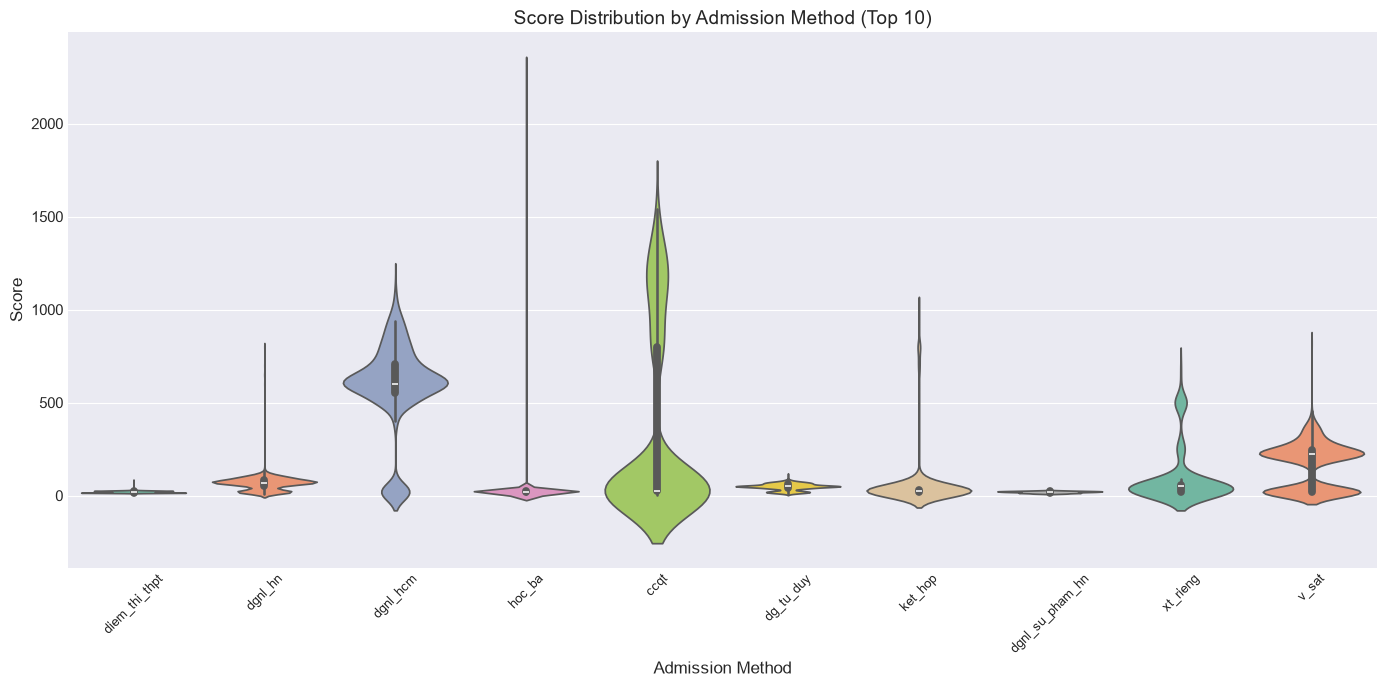


📊 Records per method:
method
diem_thi_thpt      9217
hoc_ba             5412
dgnl_hcm           3245
dgnl_hn            1686
ket_hop            1368
dg_tu_duy          1091
v_sat              1059
ccqt                773
dgnl_su_pham_hn     555
xt_rieng            273
Name: count, dtype: int64


In [14]:
# Cell 14: Score Distribution by Admission Method
fig, ax = plt.subplots(figsize=(14, 7))

top_methods = valid_scores['method'].value_counts().head(10).index.tolist()
filtered = valid_scores[valid_scores['method'].isin(top_methods)]

sns.violinplot(data=filtered, x='method', y='score', ax=ax, palette='Set2', inner='box')
ax.set_title('Score Distribution by Admission Method (Top 10)')
ax.set_xlabel('Admission Method')
ax.set_ylabel('Score')
ax.tick_params(axis='x', rotation=45, labelsize=9)

plt.tight_layout()
plt.savefig('plots/score_by_method.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Records per method:")
print(valid_scores['method'].value_counts().head(10))

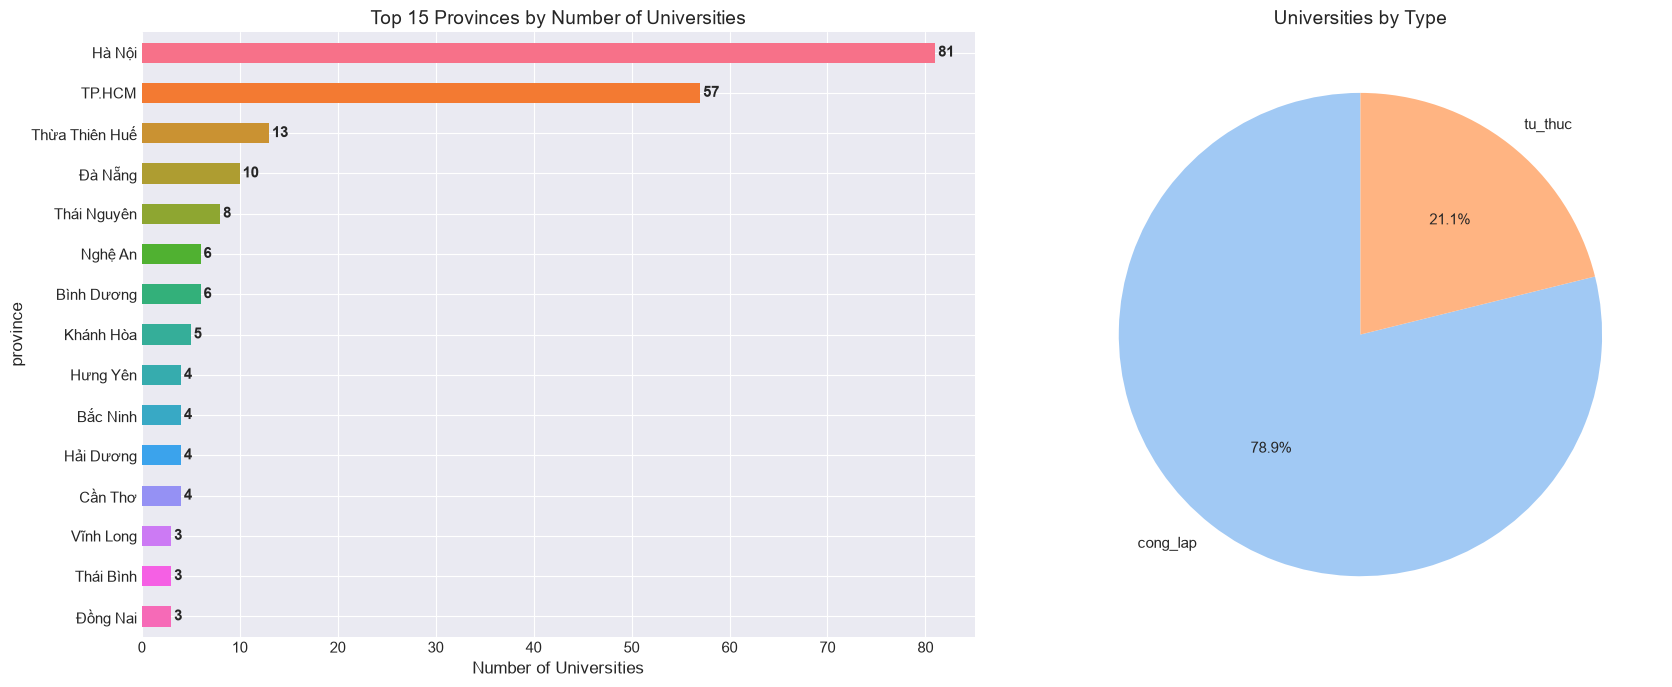

In [15]:
# Cell 15: University Distribution by Province & Type
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# By Province (Top 15)
province_counts = df_universities['province'].value_counts().head(15)
province_counts.plot(kind='barh', ax=axes[0], color=sns.color_palette('husl', 15))
axes[0].set_title('Top 15 Provinces by Number of Universities')
axes[0].set_xlabel('Number of Universities')
axes[0].invert_yaxis()
for i, v in enumerate(province_counts.values):
    axes[0].text(v + 0.3, i, str(v), va='center', fontweight='bold')

# By Type
if 'type' in df_universities.columns:
    type_counts = df_universities['type'].value_counts()
    colors = sns.color_palette('pastel', len(type_counts))
    wedges, texts, autotexts = axes[1].pie(
        type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90
    )
    axes[1].set_title('Universities by Type')

plt.tight_layout()
plt.savefig('plots/university_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

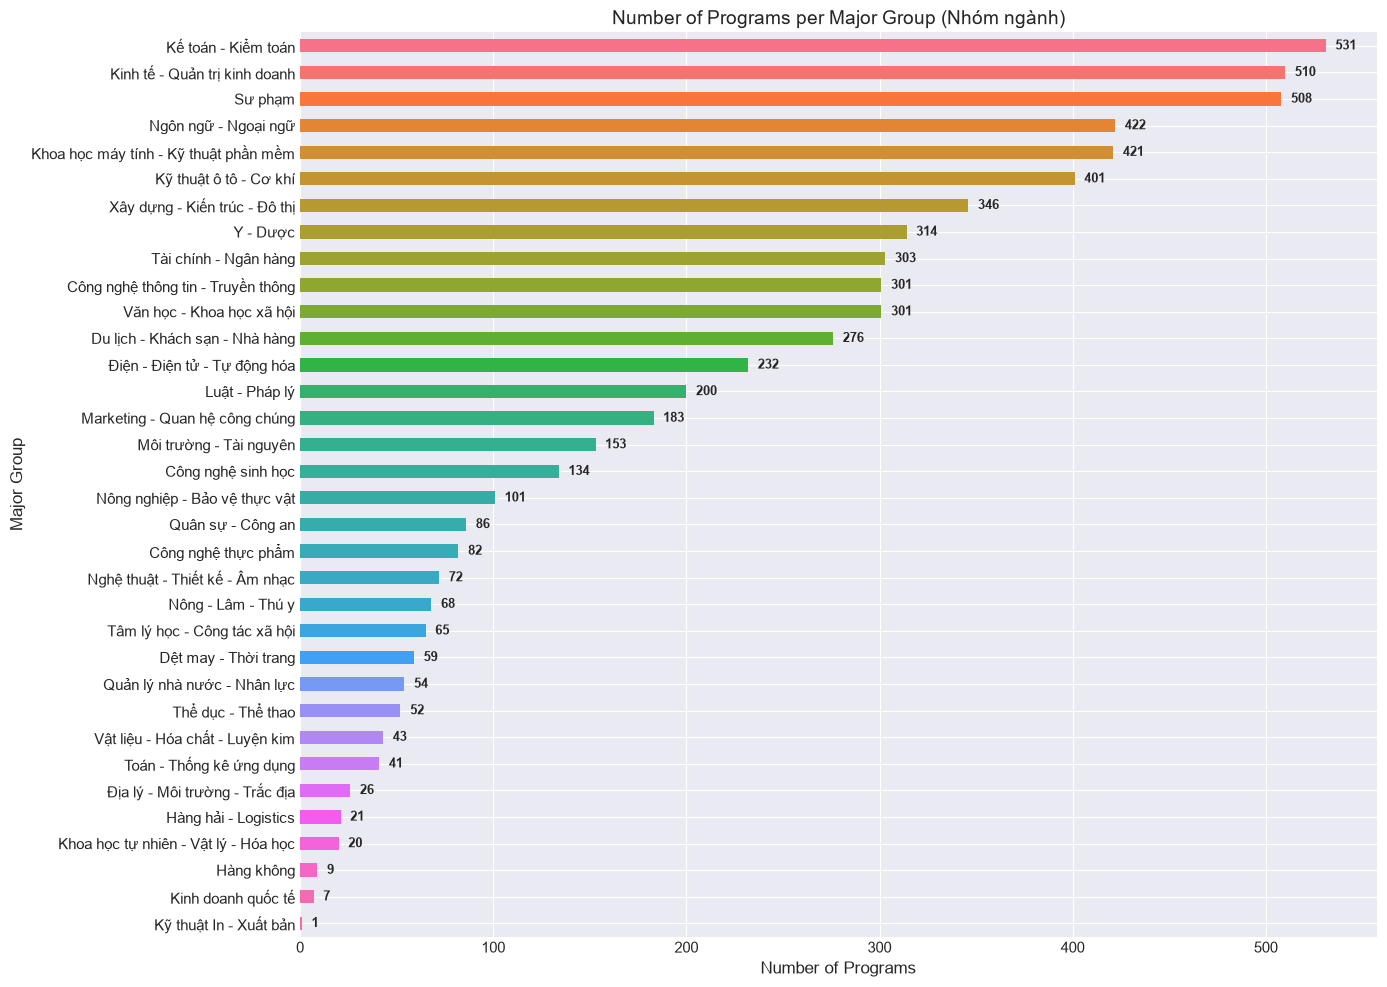


📊 Total major groups: 34
   Programs without group: 326


In [16]:
# Cell 16: Programs per Major Group (Nhóm ngành)
# Merge to get group names
df_programs_with_group = df_programs.merge(
    df_major_groups[['id', 'name']].rename(columns={'id': 'group_id', 'name': 'group_name'}), 
    left_on='major_group_id', 
    right_on='group_id', 
    how='left'
)

fig, ax = plt.subplots(figsize=(14, 10))
group_counts = df_programs_with_group['group_name'].value_counts()

colors = sns.color_palette('husl', len(group_counts))
group_counts.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Number of Programs per Major Group (Nhóm ngành)')
ax.set_xlabel('Number of Programs')
ax.set_ylabel('Major Group')
ax.invert_yaxis()

for i, v in enumerate(group_counts.values):
    ax.text(v + 5, i, str(v), va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('plots/programs_per_major_group.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Total major groups: {len(group_counts)}")
print(f"   Programs without group: {df_programs_with_group['group_name'].isna().sum()}")

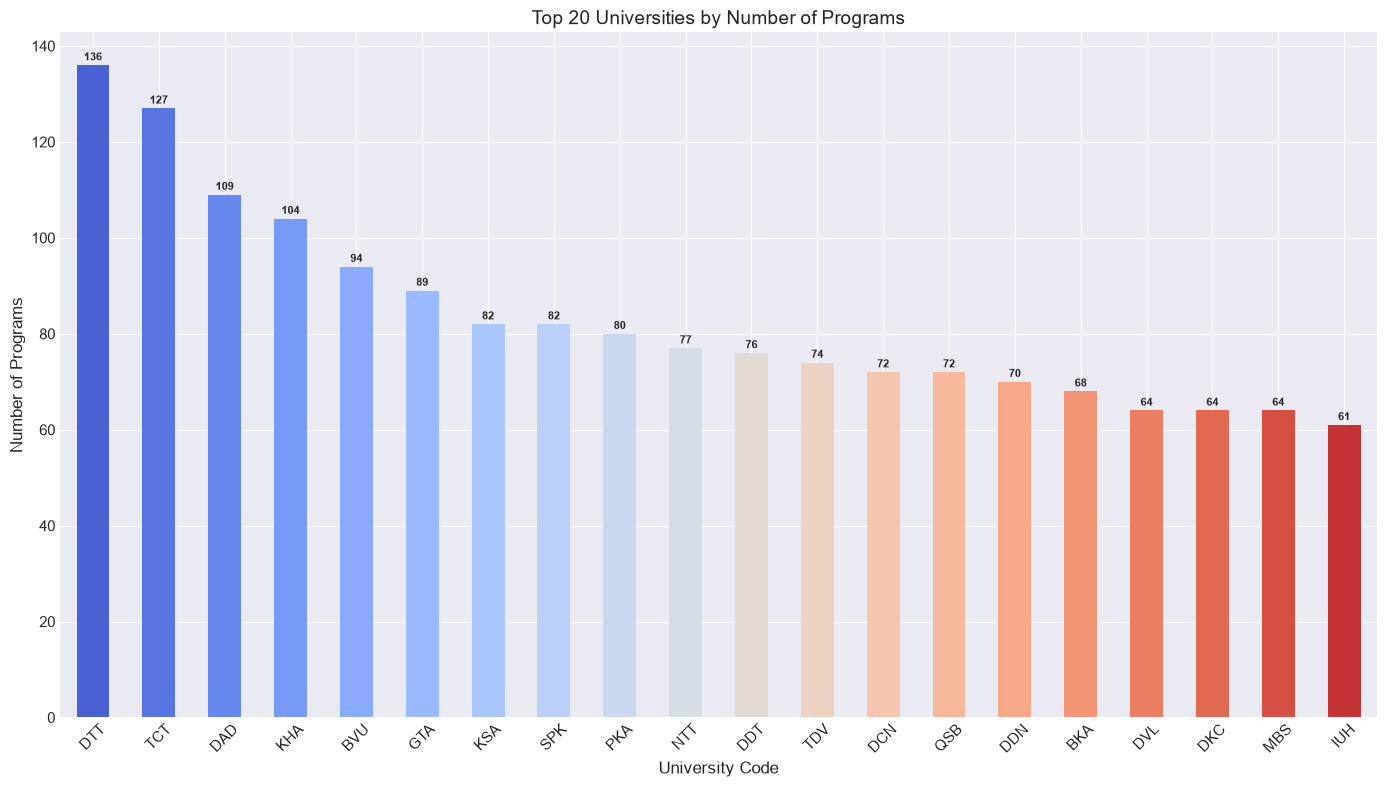


📊 University program stats:
   Total universities with programs: 287
   Mean programs/university: 23.2
   Median: 17
   Max: 136 (DTT)


In [17]:
# Cell 17: Programs per University (Top 20)
fig, ax = plt.subplots(figsize=(14, 8))

programs_per_uni = df_programs.merge(
    df_universities[['id', 'name', 'university_code']], 
    left_on='university_id', right_on='id', suffixes=('', '_uni')
)
uni_program_counts = programs_per_uni.groupby('university_code').size().sort_values(ascending=False)

top20 = uni_program_counts.head(20)
top20.plot(kind='bar', ax=ax, color=sns.color_palette('coolwarm', 20))
ax.set_title('Top 20 Universities by Number of Programs')
ax.set_xlabel('University Code')
ax.set_ylabel('Number of Programs')
ax.tick_params(axis='x', rotation=45)

for i, v in enumerate(top20.values):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=8)

plt.tight_layout()
plt.savefig('plots/programs_per_university.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 University program stats:")
print(f"   Total universities with programs: {len(uni_program_counts)}")
print(f"   Mean programs/university: {uni_program_counts.mean():.1f}")
print(f"   Median: {uni_program_counts.median():.0f}")
print(f"   Max: {uni_program_counts.max()} ({uni_program_counts.idxmax()})")

---
## 5. Outlier Detection
Phát hiện giá trị bất thường trong điểm chuẩn, học phí, chỉ tiêu.

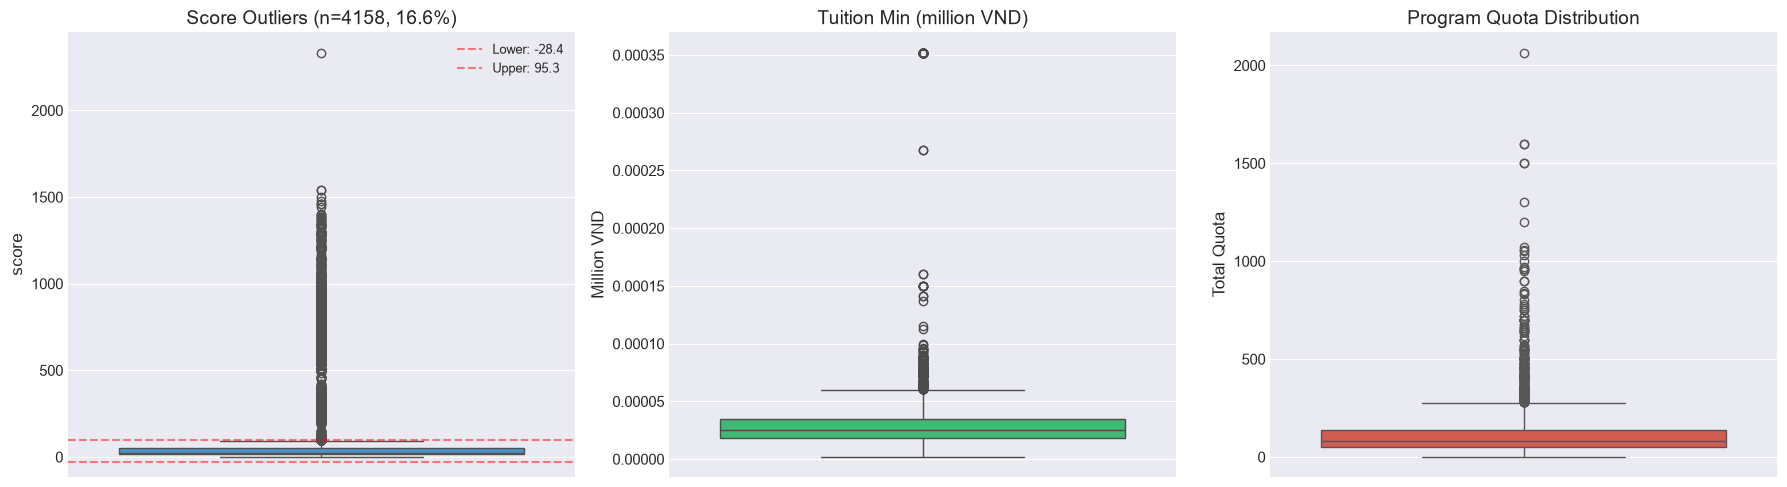


📊 Outlier Summary:
   Scores: 4158 outliers out of 25008 (16.6%)
   Score range: [1.0, 2333.0]
   IQR bounds: [-28.4, 95.3]

   Top outlier scores:
                     university_name                                                  major_name   score  year method
                    Đại Học Phenikaa Marketing (Một Số Học Phần Chuyên Ngành Học Bằng Tiếng Anh) 2333.00  2025 hoc_ba
Trường Đại Học Kinh Tế - ĐHQG Hà Nội                                   Ngành Quản trị kinh doanh 1540.00  2024   ccqt
Trường Đại Học Kinh Tế - ĐHQG Hà Nội                                 Ngành Tài chính – Ngân hàng 1540.00  2024   ccqt
                Đại Học Y Dược TPHCM                                                      Y khoa 1500.00  2024   ccqt
        Học Viện Hàng không Việt Nam                  Quản lý hoạt động bay (học bằng tiếng Anh) 1480.00  2025   ccqt


In [18]:
# Cell 18: Outlier Detection — Admission Scores
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Score outliers
q1 = valid_scores['score'].quantile(0.25)
q3 = valid_scores['score'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = valid_scores[(valid_scores['score'] < lower) | (valid_scores['score'] > upper)]

sns.boxplot(y=valid_scores['score'], ax=axes[0], color='#3498db')
axes[0].set_title(f'Score Outliers (n={len(outliers)}, {len(outliers)/len(valid_scores)*100:.1f}%)')
axes[0].axhline(lower, color='red', linestyle='--', alpha=0.5, label=f'Lower: {lower:.1f}')
axes[0].axhline(upper, color='red', linestyle='--', alpha=0.5, label=f'Upper: {upper:.1f}')
axes[0].legend(fontsize=9)

# Tuition outliers (programs)
tuition_data = df_programs[df_programs['tuition_min'].notna() & (df_programs['tuition_min'] > 0)]
if len(tuition_data) > 0:
    sns.boxplot(y=tuition_data['tuition_min'] / 1e6, ax=axes[1], color='#2ecc71')
    axes[1].set_title(f'Tuition Min (million VND)')
    axes[1].set_ylabel('Million VND')

# Quota outliers
quota_data = df_programs[df_programs['total_quota'].notna() & (df_programs['total_quota'] > 0)]
if len(quota_data) > 0:
    sns.boxplot(y=quota_data['total_quota'], ax=axes[2], color='#e74c3c')
    axes[2].set_title(f'Program Quota Distribution')
    axes[2].set_ylabel('Total Quota')

plt.tight_layout()
plt.savefig('plots/outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Outlier Summary:")
print(f"   Scores: {len(outliers)} outliers out of {len(valid_scores)} ({len(outliers)/len(valid_scores)*100:.1f}%)")
print(f"   Score range: [{valid_scores['score'].min():.1f}, {valid_scores['score'].max():.1f}]")
print(f"   IQR bounds: [{lower:.1f}, {upper:.1f}]")

if len(outliers) > 0:
    print(f"\n   Top outlier scores:")
    print(outliers.nlargest(5, 'score')[['university_name', 'major_name', 'score', 'year', 'method']].to_string(index=False))

---
## 6. Class Imbalance Analysis
Trường/Ngành nào đang bị over-represented hoặc under-represented?

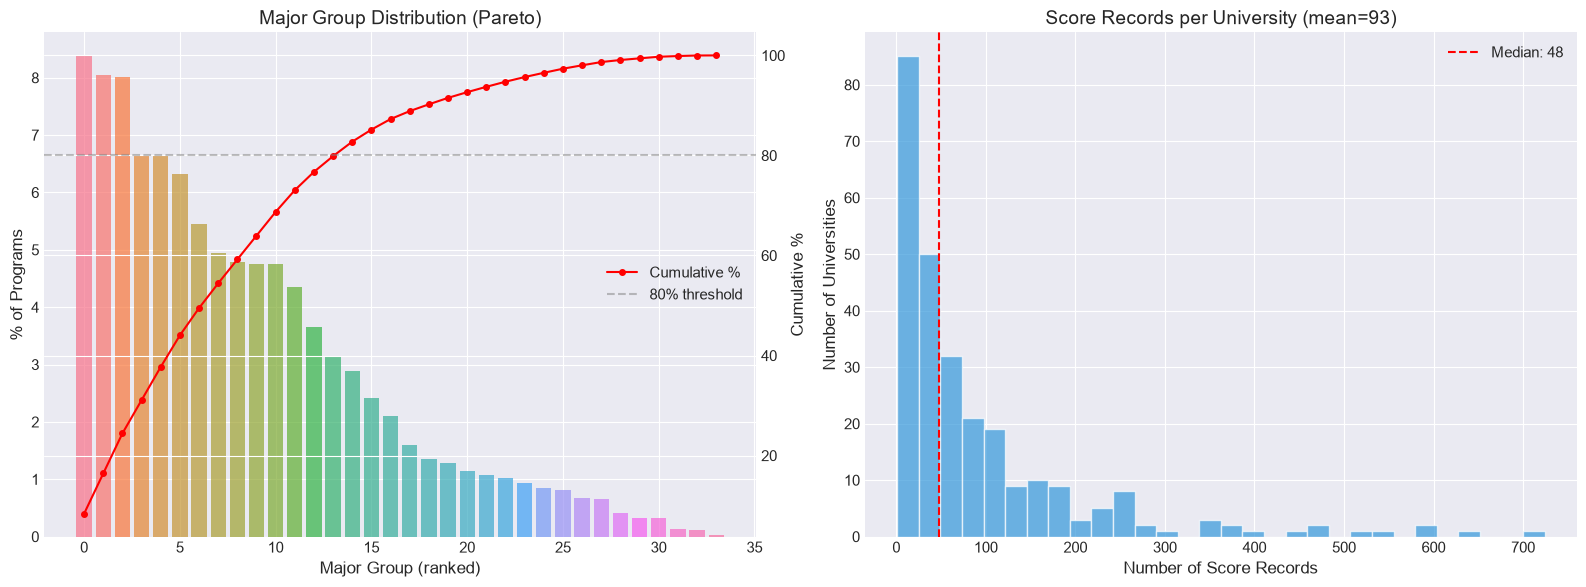


📊 IMBALANCE ANALYSIS

🔝 Top 5 Over-represented Major Groups:
   1. Kế toán - Kiểm toán: 8.4% (531 programs)
   2. Kinh tế - Quản trị kinh doanh: 8.0% (510 programs)
   3. Sư phạm: 8.0% (508 programs)
   4. Ngôn ngữ - Ngoại ngữ: 6.7% (422 programs)
   5. Khoa học máy tính - Kỹ thuật phần mềm: 6.6% (421 programs)

🔻 Bottom 5 Under-represented Major Groups:
   1. Hàng hải - Logistics: 0.3% (21 programs)
   2. Khoa học tự nhiên - Vật lý - Hóa học: 0.3% (20 programs)
   3. Hàng không: 0.1% (9 programs)
   4. Kinh doanh quốc tế: 0.1% (7 programs)
   5. Kỹ thuật In - Xuất bản: 0.0% (1 programs)


In [19]:
# Cell 19: Class Imbalance — Major Groups
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Major group representation in programs
group_dist = df_programs_with_group['group_name'].value_counts()
group_pct = (group_dist / group_dist.sum() * 100).round(2)

# Pareto chart
ax1 = axes[0]
cumulative = group_pct.cumsum()
ax1.bar(range(len(group_pct)), group_pct.values, color=sns.color_palette('husl', len(group_pct)), alpha=0.7)
ax1_twin = ax1.twinx()
ax1_twin.plot(range(len(cumulative)), cumulative.values, 'r-o', markersize=4, label='Cumulative %')
ax1_twin.set_ylabel('Cumulative %')
ax1_twin.axhline(80, color='gray', linestyle='--', alpha=0.5, label='80% threshold')
ax1_twin.legend(loc='center right')
ax1.set_title('Major Group Distribution (Pareto)')
ax1.set_xlabel('Major Group (ranked)')
ax1.set_ylabel('% of Programs')

# Score records per university (Top vs Bottom)
score_per_uni = df_admission_scores.groupby('university_name').size()
ax2 = axes[1]
ax2.hist(score_per_uni.values, bins=30, color='#3498db', alpha=0.7, edgecolor='white')
ax2.set_title(f'Score Records per University (mean={score_per_uni.mean():.0f})')
ax2.set_xlabel('Number of Score Records')
ax2.set_ylabel('Number of Universities')
ax2.axvline(score_per_uni.median(), color='red', linestyle='--', label=f'Median: {score_per_uni.median():.0f}')
ax2.legend()

plt.tight_layout()
plt.savefig('plots/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify over/under-represented
print("\n📊 IMBALANCE ANALYSIS")
print("=" * 60)
print(f"\n🔝 Top 5 Over-represented Major Groups:")
for i, (name, pct) in enumerate(group_pct.head(5).items()):
    print(f"   {i+1}. {name}: {pct:.1f}% ({group_dist[name]} programs)")

print(f"\n🔻 Bottom 5 Under-represented Major Groups:")
for i, (name, pct) in enumerate(group_pct.tail(5).items()):
    print(f"   {i+1}. {name}: {pct:.1f}% ({group_dist[name]} programs)")

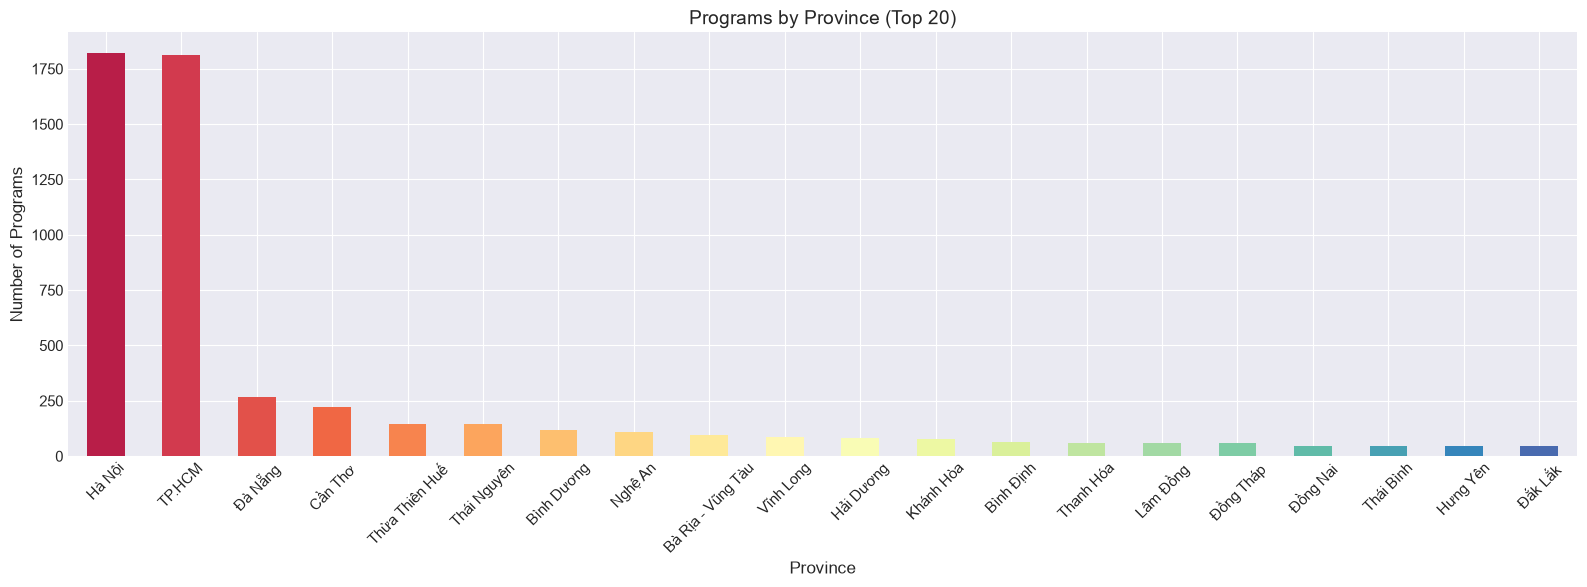


📊 Geographic Concentration:
   Top 3 provinces hold 66.6% of all programs:
   - Hà Nội: 1823 programs (31.1%)
   - TP.HCM: 1814 programs (30.9%)
   - Đà Nẵng: 265 programs (4.5%)


In [20]:
# Cell 20: Province Imbalance — Geographic distribution
fig, ax = plt.subplots(figsize=(16, 6))

province_programs = programs_per_uni.groupby('province' if 'province' in programs_per_uni.columns 
                                              else df_universities.set_index('id').loc[
                                                  programs_per_uni['university_id']
                                              ]['province'].values).size()

# Recalculate with proper merge
uni_province = df_programs.merge(
    df_universities[['id', 'province']], 
    left_on='university_id', right_on='id', suffixes=('', '_uni')
)
province_prog_counts = uni_province.groupby('province').size().sort_values(ascending=False)

province_prog_counts.head(20).plot(kind='bar', ax=ax, color=sns.color_palette('Spectral', 20))
ax.set_title('Programs by Province (Top 20)')
ax.set_xlabel('Province')
ax.set_ylabel('Number of Programs')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plots/province_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

total = province_prog_counts.sum()
top3 = province_prog_counts.head(3)
print(f"\n📊 Geographic Concentration:")
print(f"   Top 3 provinces hold {top3.sum()/total*100:.1f}% of all programs:")
for prov, cnt in top3.items():
    print(f"   - {prov}: {cnt} programs ({cnt/total*100:.1f}%)")

---
## 7. Feature Correlation & Relationship Analysis
Phân tích mối quan hệ giữa các features quan trọng.

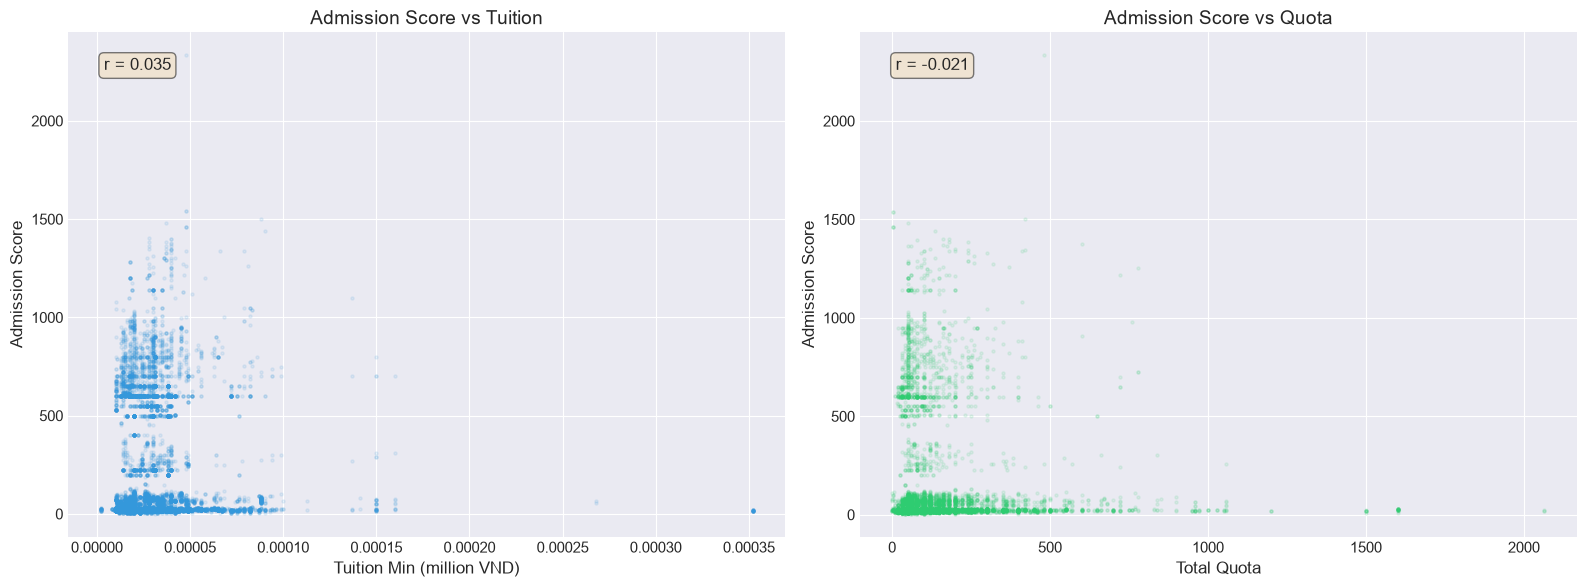

In [21]:
# Cell 21: Score vs Tuition Correlation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Merge scores with tuition
score_tuition = df_admission_scores.merge(
    df_programs[['id', 'tuition_min', 'tuition_max', 'total_quota']],
    left_on='program_id', right_on='id', suffixes=('', '_prog')
)
score_tuition = score_tuition[
    score_tuition['score'].notna() & 
    score_tuition['tuition_min'].notna() & 
    (score_tuition['score'] > 0) &
    (score_tuition['tuition_min'] > 0)
]

if len(score_tuition) > 0:
    # Score vs Tuition
    ax = axes[0]
    ax.scatter(score_tuition['tuition_min'] / 1e6, score_tuition['score'], 
               alpha=0.1, s=5, color='#3498db')
    ax.set_title('Admission Score vs Tuition')
    ax.set_xlabel('Tuition Min (million VND)')
    ax.set_ylabel('Admission Score')
    
    corr = score_tuition[['score', 'tuition_min']].corr().iloc[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Score vs Quota
score_quota = score_tuition[score_tuition['total_quota'].notna() & (score_tuition['total_quota'] > 0)]
if len(score_quota) > 0:
    ax = axes[1]
    ax.scatter(score_quota['total_quota'], score_quota['score'],
               alpha=0.1, s=5, color='#2ecc71')
    ax.set_title('Admission Score vs Quota')
    ax.set_xlabel('Total Quota')
    ax.set_ylabel('Admission Score')
    
    corr = score_quota[['score', 'total_quota']].corr().iloc[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('plots/score_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

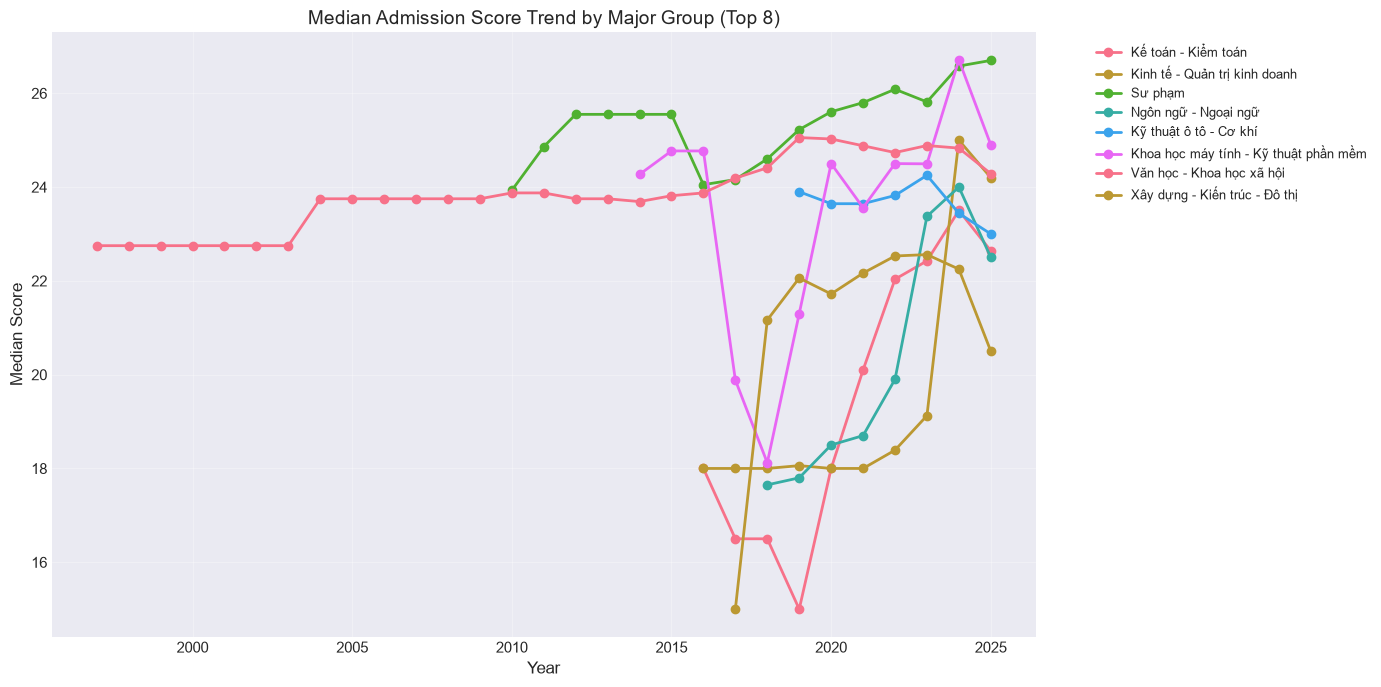

In [22]:
# Cell 22: Score Trends Over Years by Top Major Groups
fig, ax = plt.subplots(figsize=(14, 7))

# Enrich scores with major group names
score_with_group = df_admission_scores.merge(
    df_programs[['id', 'major_group_id']], 
    left_on='program_id', right_on='id', suffixes=('', '_prog')
).merge(
    df_major_groups[['id', 'name']].rename(columns={'id': 'mg_id', 'name': 'group_name'}), 
    left_on='major_group_id', right_on='mg_id'
)

# Top 8 major groups by volume
top_groups = score_with_group['group_name'].value_counts().head(8).index
filtered = score_with_group[
    score_with_group['group_name'].isin(top_groups) & 
    score_with_group['score'].notna() &
    (score_with_group['score'] > 0)
]

trend = filtered.groupby(['year', 'group_name'])['score'].median().reset_index()
for grp in top_groups:
    grp_data = trend[trend['group_name'] == grp]
    ax.plot(grp_data['year'], grp_data['score'], marker='o', linewidth=2, label=grp)

ax.set_title('Median Admission Score Trend by Major Group (Top 8)')
ax.set_xlabel('Year')
ax.set_ylabel('Median Score')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/score_trend_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. EDA Summary & Key Findings

In [23]:
# Cell 23: Summary Statistics
print("=" * 70)
print("📊 EDA SUMMARY REPORT")
print("=" * 70)

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│ DATASET OVERVIEW                                                │
├─────────────────────────────────────────────────────────────────┤
│ Universities        : {len(df_universities):>6,}                                    │
│ Programs (ngành)    : {len(df_programs):>6,}                                    │
│ Major Groups        : {len(df_major_groups):>6,}                                    │
│ Admission Scores    : {len(df_admission_scores):>6,}                                    │
│ Users               : {len(df_users):>6,}                                    │
│ Exam Attempts       : {len(df_exam_attempts):>6,}                                    │
│ Subjects            : {len(df_subjects):>6,}                                    │
├─────────────────────────────────────────────────────────────────┤
│ SCORE STATISTICS                                                │
├─────────────────────────────────────────────────────────────────┤
│ Valid scores        : {len(valid_scores):>6,}                                    │
│ Mean score          : {valid_scores['score'].mean():>8.2f}                                  │
│ Median score        : {valid_scores['score'].median():>8.2f}                                  │
│ Std dev             : {valid_scores['score'].std():>8.2f}                                  │
│ Years covered       : {sorted(valid_scores['year'].unique())}  │
├─────────────────────────────────────────────────────────────────┤
│ DATA QUALITY                                                    │
├─────────────────────────────────────────────────────────────────┤
│ User data           : ⚠️ SPARSE (only {len(df_users)} users)                      │
│ Interaction data    : ❌ MISSING (0 answer records)                │
│ MBTI/Holland        : ❌ NOT AVAILABLE                              │
│ Item metadata       : ✅ RICH                                       │
│ Score history       : ✅ COMPREHENSIVE                              │
└─────────────────────────────────────────────────────────────────┘
""")

print("\n🏁 EDA Complete. Ready for Phase 3: Recommendation System Architecture.")

📊 EDA SUMMARY REPORT

┌─────────────────────────────────────────────────────────────────┐
│ DATASET OVERVIEW                                                │
├─────────────────────────────────────────────────────────────────┤
│ Universities        :    287                                    │
│ Programs (ngành)    :  6,669                                    │
│ Major Groups        :     35                                    │
│ Admission Scores    : 25,015                                    │
│ Users               :     27                                    │
│ Exam Attempts       :     12                                    │
│ Subjects            :     16                                    │
├─────────────────────────────────────────────────────────────────┤
│ SCORE STATISTICS                                                │
├─────────────────────────────────────────────────────────────────┤
│ Valid scores        : 25,008                                    │
│ Mean score          :   